# Logistic Regression — Theory, Implementation & Evaluation


## 1. From Regression to Classification

we learned Linear Regression — a model that predicts a **continuous** number (like house prices). But what if the thing we want to predict is not a number, but a **category**? For example:

- Will this email be spam or not spam?
- Will this patient have diabetes or not?
- Will this customer churn or stay?

These are **classification** problems. The output is not a number on a continuous scale — it is a discrete label, often just 0 or 1 (No or Yes).

Now, you might wonder: can we just use Linear Regression for this? We could assign 0 to one class and 1 to the other, then fit a line. The problem is that Linear Regression outputs values from $-\infty$ to $+\infty$. It can predict 2.7 or -0.5, which make no sense as probabilities. We need a model that outputs values **between 0 and 1**, which we can interpret as the probability of belonging to a particular class.

This is exactly what **Logistic Regression** does.

## 2. What is Logistic Regression?

Despite its name, Logistic Regression is a **classification** algorithm, not a regression algorithm. The name comes from the mathematical function at its core — the **logistic function** (also called the sigmoid function).

Here is the idea in two steps:

**Step 1:** Just like Linear Regression, we compute a weighted sum of the input features:

$$z = w_0 + w_1 x_1 + w_2 x_2 + \ldots + w_n x_n$$

This value $z$ can range from $-\infty$ to $+\infty$.

**Step 2:** We pass $z$ through the **sigmoid function** to squash it into the range (0, 1):

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

The output $\sigma(z)$ is now a **probability** — the probability that the input belongs to the positive class (class 1).

### The Sigmoid Function — Intuition

The sigmoid function has a beautiful S-shaped curve:
- When $z$ is a large positive number → $\sigma(z) \approx 1$ (model is confident it is class 1)
- When $z$ is a large negative number → $\sigma(z) \approx 0$ (model is confident it is class 0)
- When $z = 0$ → $\sigma(z) = 0.5$ (model is uncertain, right on the decision boundary)

### The Decision Rule

Once we have the probability, we need a rule to make the final classification. The default rule is simple:

- If $\sigma(z) \geq 0.5$ → predict **class 1**
- If $\sigma(z) < 0.5$ → predict **class 0**

The threshold of 0.5 is the default, but it can be adjusted depending on the problem (we will touch on this later).

## 3. How Does It Learn? — The Log Loss (Binary Cross-Entropy)

In Linear Regression, we minimized the Mean Squared Error. For Logistic Regression, MSE is not suitable because the sigmoid function makes the error surface non-convex with MSE — meaning gradient descent could get stuck in local minima.

Instead, Logistic Regression uses a cost function called **Log Loss** (also known as **Binary Cross-Entropy**):

$$\text{Log Loss} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{p}_i) + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

Where $\hat{p}_i$ is the predicted probability for the $i$-th sample.

Let us break down why this works:

- **When the actual label is 1** ($y_i = 1$): the cost becomes $-\log(\hat{p}_i)$. If the model predicts a probability close to 1, $\log(1) = 0$, so the cost is near zero. If the model predicts close to 0, $\log(0) \to -\infty$, so the cost is extremely high. The model is heavily penalized for being confidently wrong.

- **When the actual label is 0** ($y_i = 0$): the cost becomes $-\log(1 - \hat{p}_i)$. Now the model is penalized for predicting a high probability when the truth is 0.

This cost function is **convex**, which means gradient-based optimization will always find the global minimum. Scikit-learn uses optimized solvers (like LBFGS) to minimize this cost and find the best weights.

## 4. Key Differences: Linear Regression vs Logistic Regression

It is important to clearly understand how these two models differ, since the names are similar but the purposes are fundamentally different:

| Aspect | Linear Regression | Logistic Regression |
|--------|-------------------|---------------------|
| **Task** | Regression (predict a continuous value) | Classification (predict a category) |
| **Output** | Any real number ($-\infty$ to $+\infty$) | Probability between 0 and 1 |
| **Activation** | None (identity) | Sigmoid function |
| **Cost Function** | Mean Squared Error | Log Loss (Binary Cross-Entropy) |
| **Decision Boundary** | A line/hyperplane for prediction | A line/hyperplane separating classes |
| **Evaluation Metrics** | MAE, RMSE, R² | Accuracy, Precision, Recall, F1, AUC-ROC |

---

## 5. Let's Start Coding — Setup and Imports

Now that we understand the theory, let us move to the practical side. We will import the libraries we need for data handling, visualization, model building, and evaluation.

**Task:** Import all required libraries.

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, roc_auc_score)
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


## 6. Visualizing the Sigmoid Function

Before we dive into the dataset, let us actually **see** the sigmoid function. This will make the theory we discussed concrete and visual. We will plot it and mark the key regions.

**Task:** Define the sigmoid function and plot it.

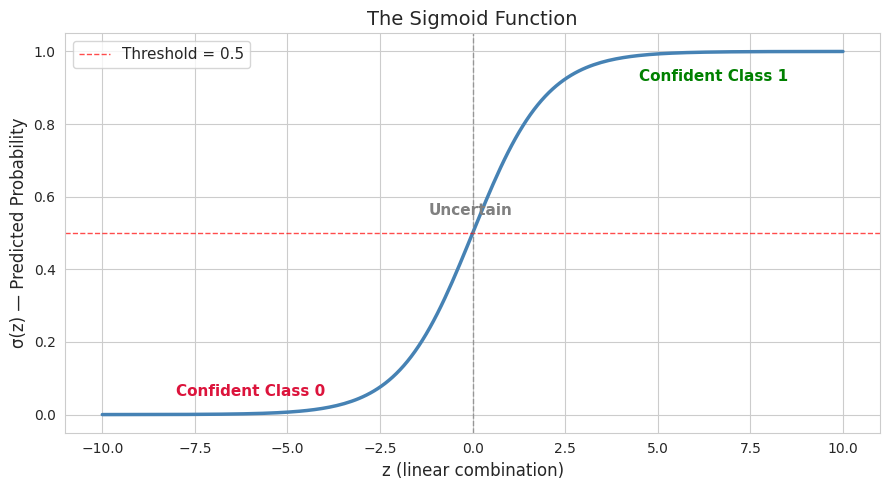

In [108]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)
sig = sigmoid(z)

plt.figure(figsize=(9, 5))
plt.plot(z, sig, color='steelblue', linewidth=2.5)

plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Threshold = 0.5')
plt.axvline(x=0, color='grey', linestyle='--', linewidth=1, alpha=0.7)

plt.annotate('Confident Class 0', xy=(-8, 0.05), fontsize=11, color='crimson', fontweight='bold')
plt.annotate('Uncertain', xy=(-1.2, 0.55), fontsize=11, color='grey', fontweight='bold')
plt.annotate('Confident Class 1', xy=(4.5, 0.92), fontsize=11, color='green', fontweight='bold')

plt.title('The Sigmoid Function', fontsize=14)
plt.xlabel('z (linear combination)', fontsize=12)
plt.ylabel('σ(z) — Predicted Probability', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 7. Loading and Exploring the Dataset

For this lecture, we will use the **Breast Cancer Wisconsin dataset**. This is a classic binary classification dataset built into Scikit-learn. Each sample represents a cell nucleus from a breast mass, and the features describe characteristics like radius, texture, perimeter, area, smoothness, and so on. The target variable tells us whether the tumor is **malignant** (cancerous, labeled 0) or **benign** (not cancerous, labeled 1).

This is a meaningful real-world problem — and it is exactly the kind of task Logistic Regression excels at.

**Task:** Load the Breast Cancer dataset and convert it to a DataFrame.

In [109]:
# Import load_breast_cancer from sklearn.datasets
# Load the dataset (use as_frame=True)
# Separate features (X) and target (y)
# Display the first 5 rows of the features DataFrame

from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)

X = cancer.data
y = cancer.target

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [110]:
cancer_df = cancer.frame

In [111]:
cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


0 = Maligant
1 = Benign

### Understanding the Data

Let us explore the shape, features, and basic statistics of this dataset. We also want to understand the **class distribution** — how many samples are malignant vs benign. If the classes are heavily imbalanced, that affects how we train and evaluate the model.

**Task:** Check the shape, data types, summary statistics, and class distribution.

In [112]:
print(f"Dataset shape: {X.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")
print()
X.info()

Dataset shape: (569, 30)

Feature columns (30):
   1. mean radius
   2. mean texture
   3. mean perimeter
   4. mean area
   5. mean smoothness
   6. mean compactness
   7. mean concavity
   8. mean concave points
   9. mean symmetry
  10. mean fractal dimension
  11. radius error
  12. texture error
  13. perimeter error
  14. area error
  15. smoothness error
  16. compactness error
  17. concavity error
  18. concave points error
  19. symmetry error
  20. fractal dimension error
  21. worst radius
  22. worst texture
  23. worst perimeter
  24. worst area
  25. worst smoothness
  26. worst compactness
  27. worst concavity
  28. worst concave points
  29. worst symmetry
  30. worst fractal dimension

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             

In [113]:
X = cancer.data
y = cancer.target

In [114]:
# Print the shape of X
X.shape

(569, 30)

In [115]:
# Print the column names (there are 30 features)
X.columns


Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='str')

In [116]:
# Display .info() to check data types and non-null counts
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [117]:
# Display summary statistics with .describe()
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [118]:
# Check the class distribution of the target variable
# Hint: use y.value_counts()
print(y.value_counts())


target
1    357
0    212
Name: count, dtype: int64


In [119]:
# Also print as percentages using y.value_counts(normalize=True)

# Note: 0 = malignant, 1 = benign
y.value_counts(normalize=True).round(3)

target
1    0.627
0    0.373
Name: proportion, dtype: float64

In [120]:
print("Class Distribution:")
print(y.value_counts())
print()
print("Class Proportions:")
print(y.value_counts(normalize=True).round(3))
print("\n0 = Malignant | 1 = Benign")

Class Distribution:
target
1    357
0    212
Name: count, dtype: int64

Class Proportions:
target
1    0.627
0    0.373
Name: proportion, dtype: float64

0 = Malignant | 1 = Benign


### Checking for Missing Values

**Task:** Verify there are no missing values.

In [121]:
# Check for missing values
# Hint: use .isnull().sum().sum() for a quick total count
print(f"Total missing values: {X.isnull().sum().sum()}")


Total missing values: 0


## 8. Exploratory Data Analysis (EDA)

### 8.1 Class Distribution — Visual

Let us visualize the class balance with a bar chart so we can see it at a glance.

**Task:** Create a count plot of the target variable.

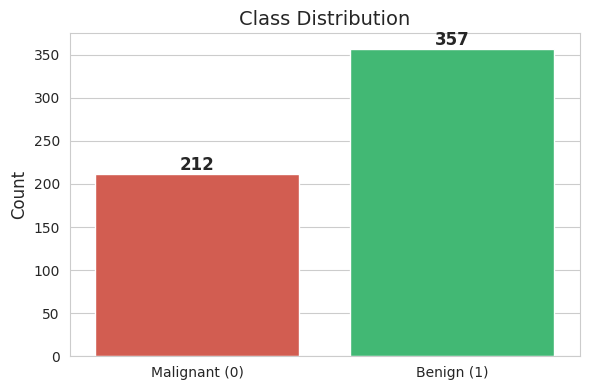

In [122]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    x=y,
    hue=y,
    palette=['#e74c3c', '#2ecc71'],
    legend=False
)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Malignant (0)', 'Benign (1)'])

plt.title('Class Distribution', fontsize=14)
plt.ylabel('Count', fontsize=12)
plt.xlabel('')

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

### 8.2 Feature Distributions by Class

A powerful way to understand which features are useful for classification is to look at how the feature values differ between the two classes. If a feature has clearly separated distributions for class 0 and class 1, it will likely be a good predictor.

We will pick a few key features and plot their distributions colored by class.

**Task:** Plot distributions of selected features, colored by target class.

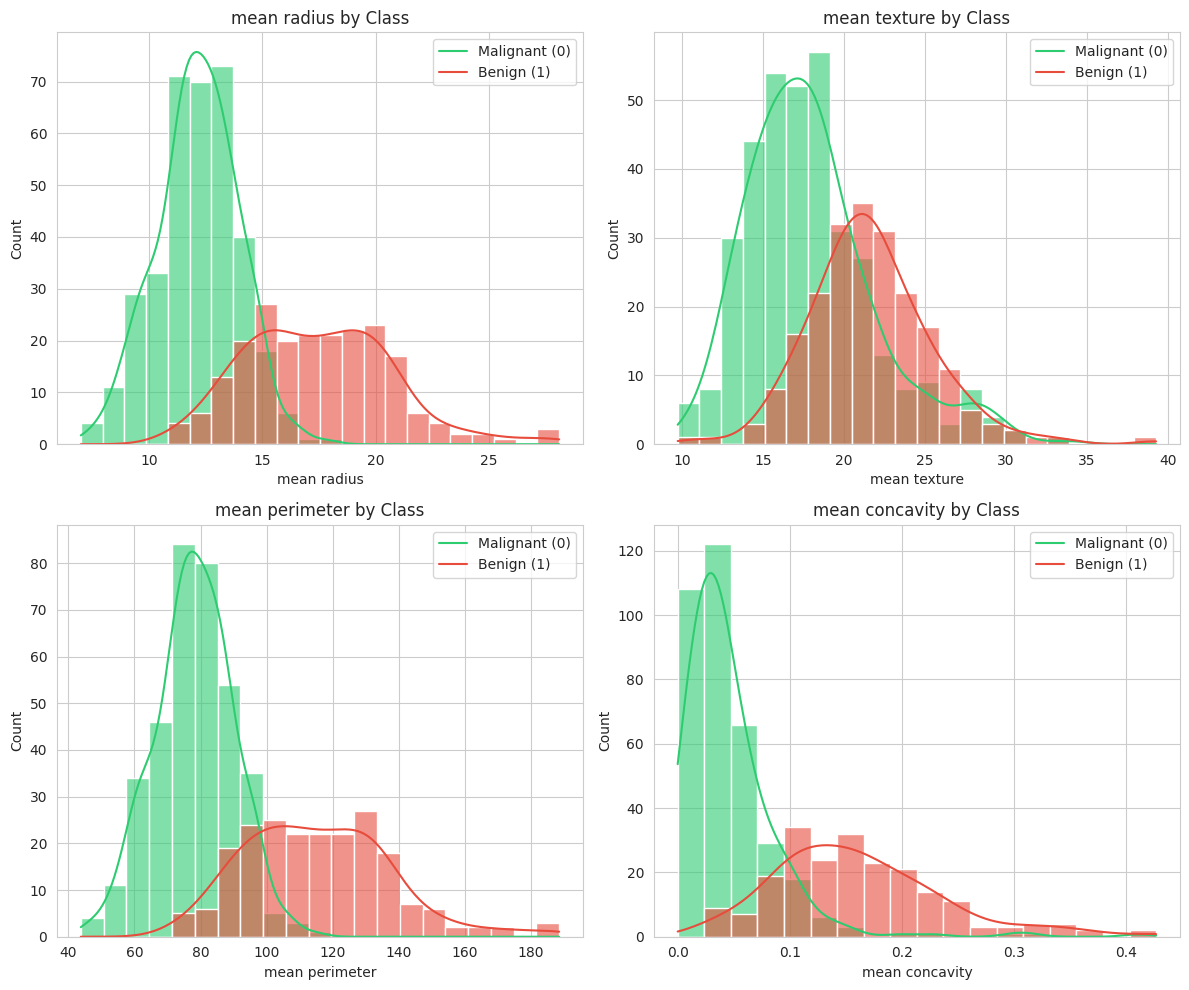

In [123]:
features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 'mean concavity']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, feature in enumerate(features_to_plot):
    sns.histplot(data=X, x=feature, hue=y, kde=True, alpha=0.6,
                 ax=axes[i], palette=['#e74c3c', '#2ecc71'])
    axes[i].set_title(f'{feature} by Class', fontsize=12)
    axes[i].legend(['Malignant (0)', 'Benign (1)'])

plt.tight_layout()
plt.show()

### 8.3 Correlation Heatmap (Top Features)

With 30 features, a full correlation heatmap would be crowded. Let us focus on the first 10 features (the "mean" features) and the target.

**Task:** Compute and plot a correlation heatmap for the mean features and target.

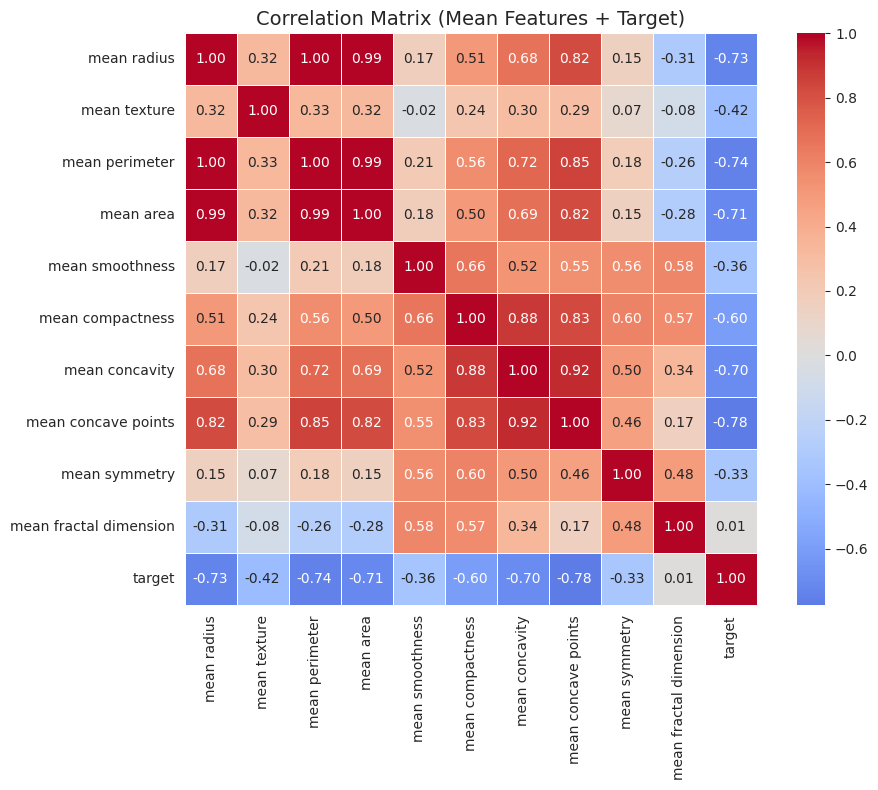

In [124]:
mean_features = X.iloc[:, :10]
df_corr = mean_features.copy()
df_corr['target'] = y

corr_matrix = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix (Mean Features + Target)', fontsize=14)
plt.tight_layout()
plt.show()

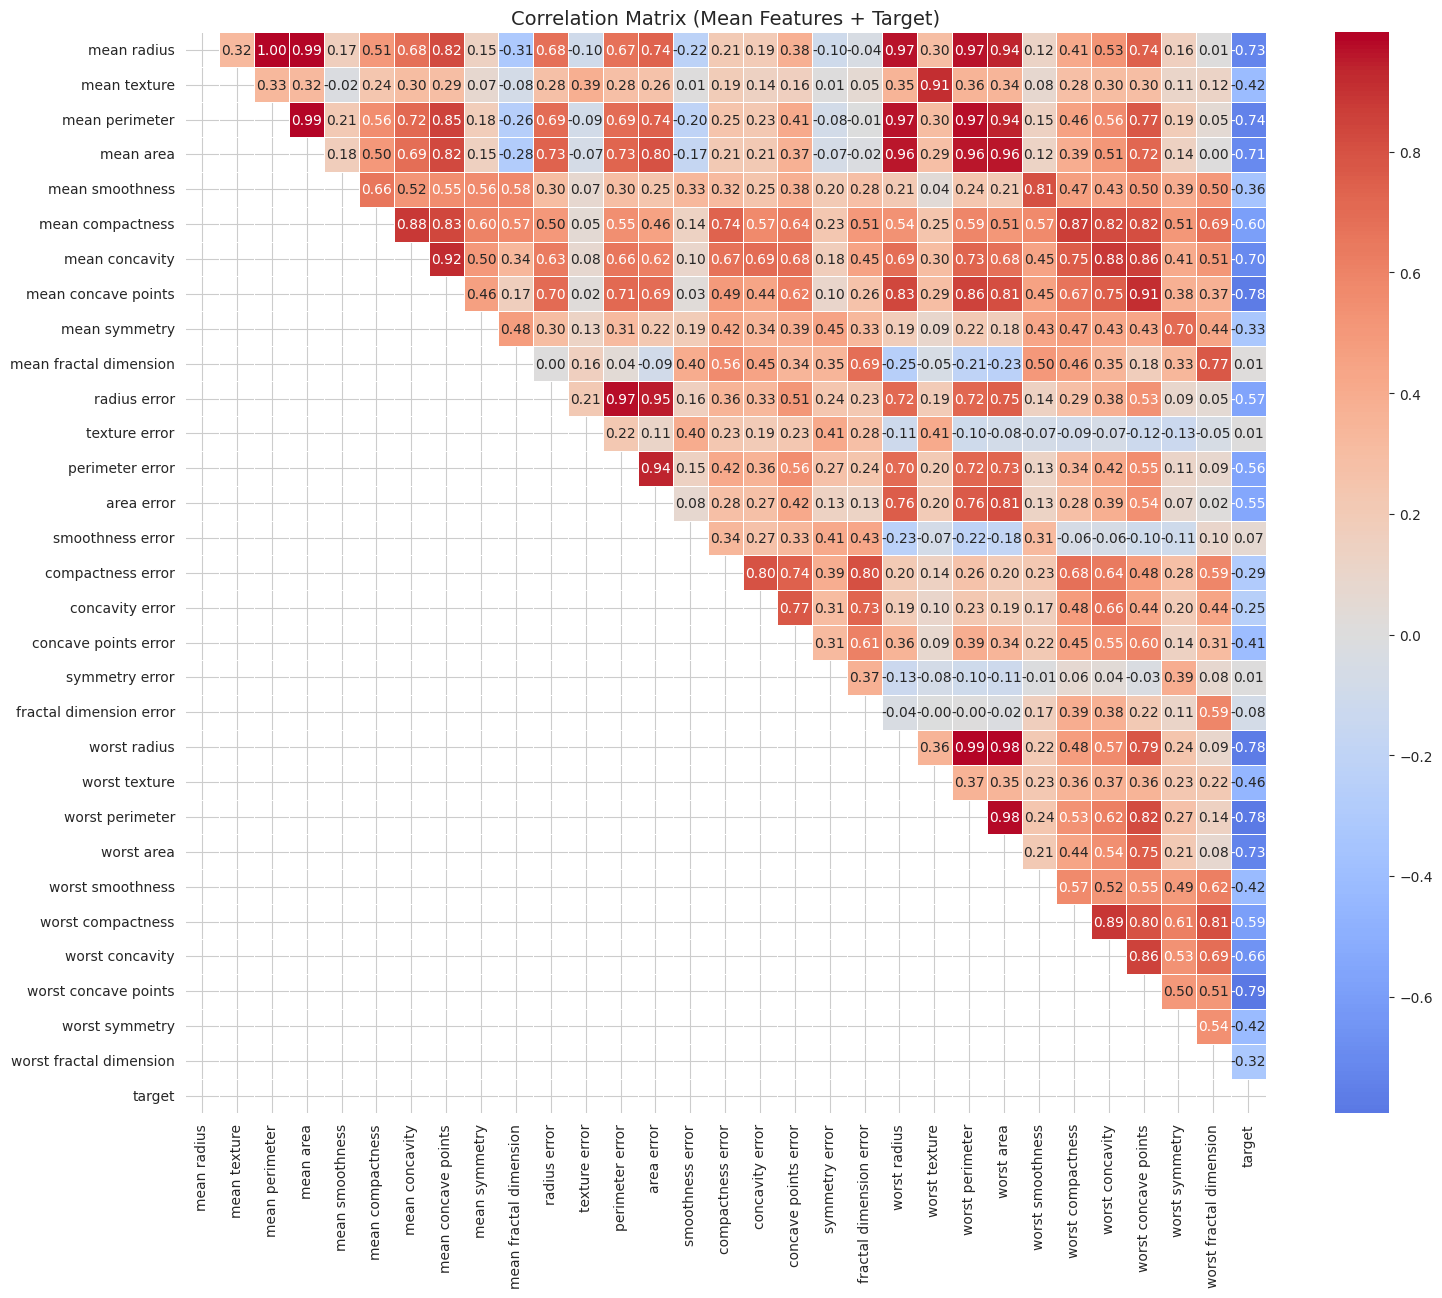

In [125]:

mean_features = X
df_corr = mean_features.copy()
df_corr['target'] = y

corr_matrix = df_corr.corr()

# Create mask for lower triangle
mask = np.tril(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16, 13))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix (Mean Features + Target)', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Data Preparation

### 9.1 Train/Test Split

Just like with Linear Regression, we split the data into training and test sets. For classification, we add one extra detail: `stratify=y`. This ensures that the class proportions are preserved in both the training and test sets. Without stratification, a random split might accidentally put most of one class in one set.

**Task:** Split the data with stratification.

In [126]:
X = cancer.data
y = cancer.target

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [127]:
# Split X and y into training and test sets
# Use test_size=0.2, random_state=42, and stratify=y
# Print the shapes of X_train, X_test
# Verify stratification by printing y_train.value_counts(normalize=True)
# and y_test.value_counts(normalize=True)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTraining class proportions:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nTest class proportions:")
print(y_test.value_counts(normalize=True).round(3))

Training set: 455 samples
Test set:     114 samples

Training class proportions:
target
1    0.626
0    0.374
Name: proportion, dtype: float64

Test class proportions:
target
1    0.632
0    0.368
Name: proportion, dtype: float64


### 9.2 Feature Scaling

This is an important step for Logistic Regression that we did not need for Linear Regression (with OLS). Logistic Regression uses gradient-based optimization, and features on very different scales can slow down convergence or cause the solver to struggle.

**StandardScaler** transforms each feature to have mean = 0 and standard deviation = 1. The critical rule is: we **fit** the scaler on the training data only, then **transform** both training and test data. If we fit on the full dataset, we leak information from the test set into the training process.

**Task:** Scale the features using StandardScaler.

In [128]:
# Create a StandardScaler instance
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"After scaling (first feature):")
print(f"  Train — Mean: {X_train_scaled[:, 0].mean():.4f}, Std: {X_train_scaled[:, 0].std():.4f}")
print(f"  Test  — Mean: {X_test_scaled[:, 0].mean():.4f}, Std: {X_test_scaled[:, 0].std():.4f}")


After scaling (first feature):
  Train — Mean: -0.0000, Std: 1.0000
  Test  — Mean: 0.0858, Std: 1.0329


## 10. Building the Logistic Regression Model

Now we build and train our Logistic Regression model. Scikit-learn makes this straightforward — the API is identical to Linear Regression. We create the model, call `.fit()`, and the solver optimizes the log loss to find the best weights.

**Task:** Create and train a Logistic Regression model.

In [129]:
# Create a LogisticRegression model instance
# Use random_state=42 and max_iter=1000 (to ensure convergence)
# Fit the model on X_train_scaled and y_train
# Print a confirmation message

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Model training complete!")

Model training complete!


### Inspecting the Learned Parameters

Just like Linear Regression, Logistic Regression learns coefficients for each feature. Here, a positive coefficient means that as the feature increases, the model becomes **more confident** the sample is class 1 (benign). A negative coefficient means the feature pushes toward class 0 (malignant).

**Task:** Display the model's coefficients and intercept.

In [130]:
# Access model.coef_ (it will be a 2D array with shape (1, n_features))
# Flatten it with model.coef_[0] or .ravel()

# For each feature name and coefficient, print them
# Hint: zip(X.columns, model.coef_[0])

# Print the intercept: model.intercept_[0]
print("Learned Coefficients:")
print("-" * 45)
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"  {feature:28s} : {coef:+.4f}")

print(f"\n  {'Intercept':28s} : {model.intercept_[0]:+.4f}")


Learned Coefficients:
---------------------------------------------
  mean radius                  : -0.5115
  mean texture                 : -0.5527
  mean perimeter               : -0.4763
  mean area                    : -0.5411
  mean smoothness              : -0.2125
  mean compactness             : +0.6483
  mean concavity               : -0.6021
  mean concave points          : -0.7042
  mean symmetry                : -0.1672
  mean fractal dimension       : +0.1997
  radius error                 : -1.0830
  texture error                : +0.2488
  perimeter error              : -0.5443
  area error                   : -0.9291
  smoothness error             : -0.1603
  compactness error            : +0.6472
  concavity error              : +0.1606
  concave points error         : -0.4438
  symmetry error               : +0.3605
  fractal dimension error      : +0.4379
  worst radius                 : -0.9476
  worst texture                : -1.2551
  worst perimeter             

### Visualizing Feature Importances

With 30 features, a printed list is hard to digest. Let us create a horizontal bar chart showing the coefficients sorted by magnitude. This gives us an immediate visual sense of which features matter most.

**Task:** Create a bar chart of the top features by coefficient magnitude.

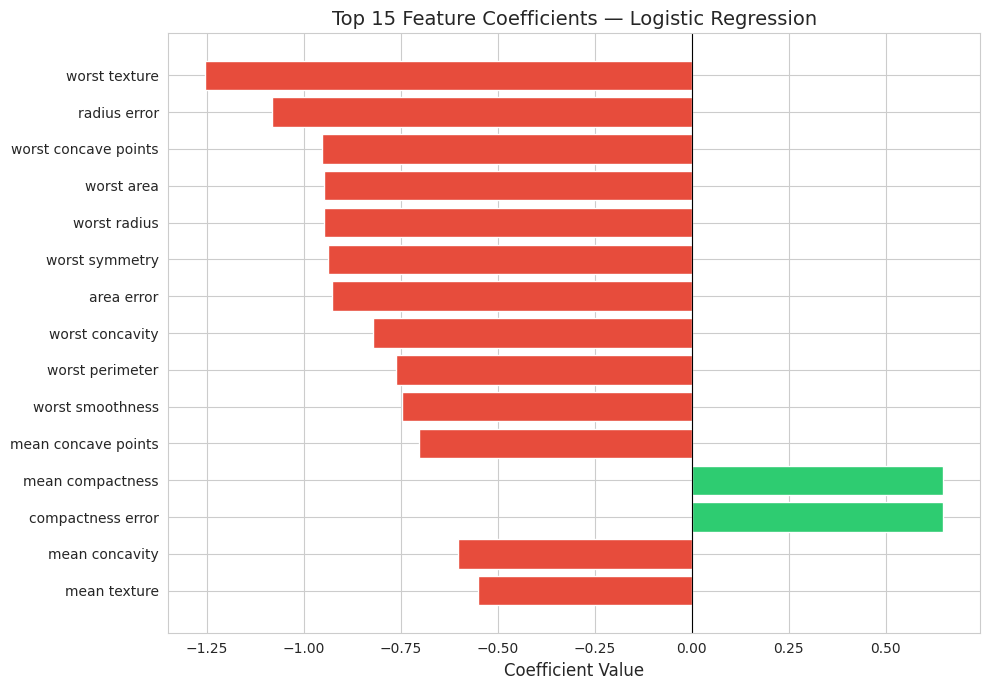

Green = pushes toward Benign (1) | Red = pushes toward Malignant (0)


In [131]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=True).tail(15)

colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coefficient']]

plt.figure(figsize=(10, 7))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top 15 Feature Coefficients — Logistic Regression', fontsize=14)
plt.xlabel('Coefficient Value', fontsize=12)
plt.tight_layout()
plt.show()

print("Green = pushes toward Benign (1) | Red = pushes toward Malignant (0)")

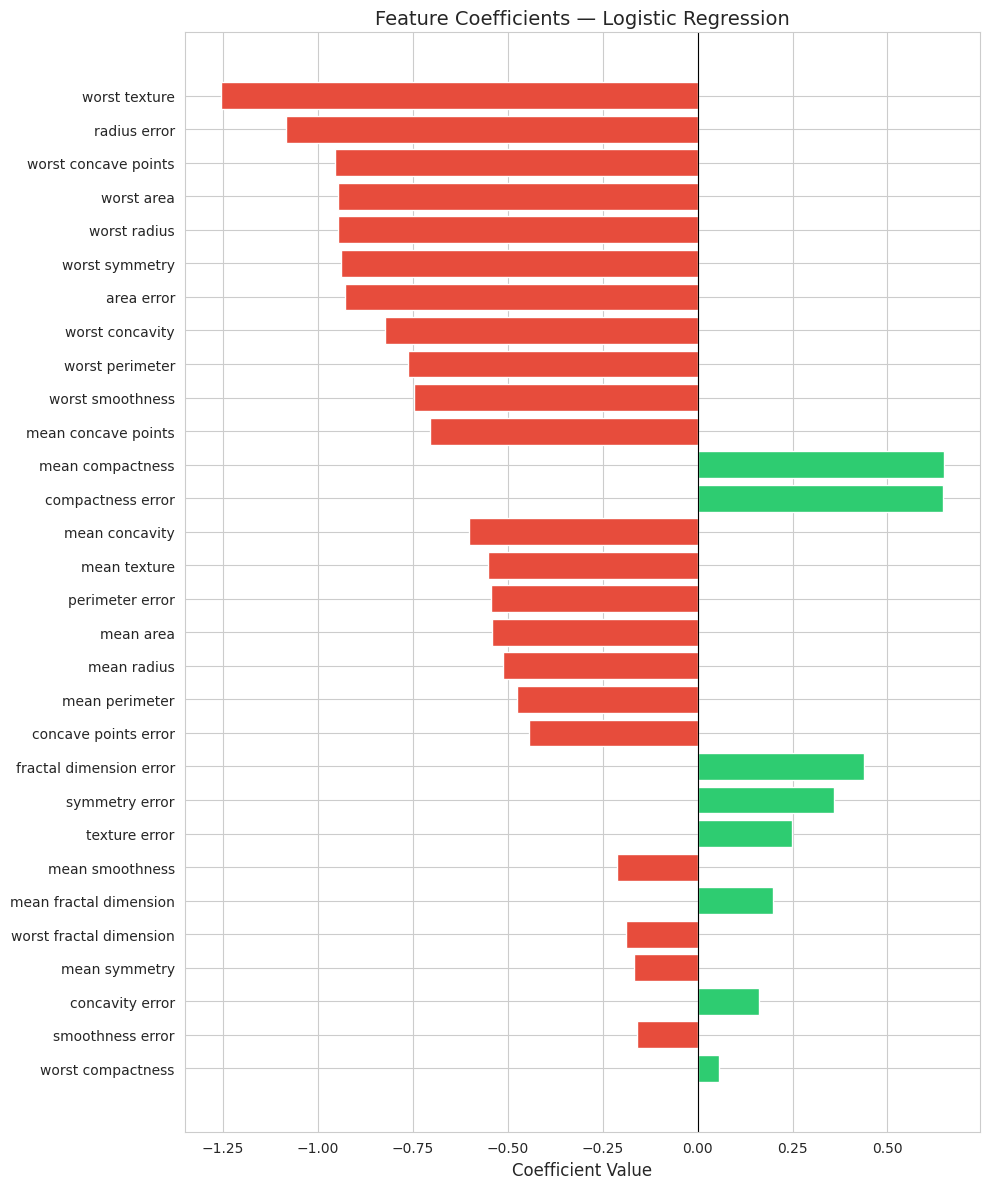

Green = pushes toward Benign (1) | Red = pushes toward Malignant (0)


In [132]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

# Sort by absolute importance
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=True)

colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coefficient']]

plt.figure(figsize=(10, 12))  # increase height for readability
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)

plt.axvline(x=0, color='black', linewidth=0.8)

plt.title('Feature Coefficients — Logistic Regression', fontsize=14)
plt.xlabel('Coefficient Value', fontsize=12)

plt.tight_layout()
plt.show()

print("Green = pushes toward Benign (1) | Red = pushes toward Malignant (0)")

## 11. Making Predictions

Logistic Regression gives us two kinds of predictions:

1. **Class predictions** (`.predict()`) — the final 0 or 1 label
2. **Probability predictions** (`.predict_proba()`) — the probability for each class

The probability predictions are especially valuable because they tell us *how confident* the model is, not just what it predicts.

**Task:** Generate both class predictions and probability predictions on the test set.

In [133]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)

comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10],
    'P(Malignant)': y_proba[:10, 0].round(4),
    'P(Benign)': y_proba[:10, 1].round(4),
})

print("First 10 Predictions:")
print(comparison.to_string(index=False))

First 10 Predictions:
 Actual  Predicted  P(Malignant)  P(Benign)
      0          0        1.0000     0.0000
      1          1        0.0000     1.0000
      0          0        0.9936     0.0064
      1          1        0.4665     0.5335
      0          0        1.0000     0.0000
      1          1        0.0078     0.9922
      1          1        0.0000     1.0000
      0          0        1.0000     0.0000
      0          0        0.9999     0.0001
      0          0        1.0000     0.0000


## 12. Model Evaluation

Classification evaluation is richer than regression evaluation because we care about different kinds of errors. Let us go through the key metrics one by one.

### 12.1 Accuracy

$$\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Predictions}}$$

Accuracy is the simplest metric — what fraction of predictions did the model get right? It is intuitive but can be **misleading** with imbalanced classes. If 95% of emails are not spam, a model that always predicts "not spam" has 95% accuracy but is completely useless.

**Task:** Compute the accuracy on the test set.

In [134]:
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, roc_auc_score)

In [135]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f} ({accuracy:.1%})")

Test Accuracy: 0.9825 (98.2%)


### 12.2 Confusion Matrix

The confusion matrix is the most informative single view of a classifier's performance. It breaks down predictions into four categories:

|  | **Predicted 0** | **Predicted 1** |
|--|:---:|:---:|
| **Actual 0** | True Negative (TN) | False Positive (FP) |
| **Actual 1** | False Negative (FN) | True Positive (TP) |

- **True Positive (TP):** Model correctly predicted class 1
- **True Negative (TN):** Model correctly predicted class 0
- **False Positive (FP):** Model predicted class 1, but the actual was class 0 (a "false alarm")
- **False Negative (FN):** Model predicted class 0, but the actual was class 1 (a "miss")

In the medical context: a False Negative (predicting benign when the tumor is actually malignant) is far more dangerous than a False Positive. This is why accuracy alone is not enough.

**Task:** Compute and visualize the confusion matrix.

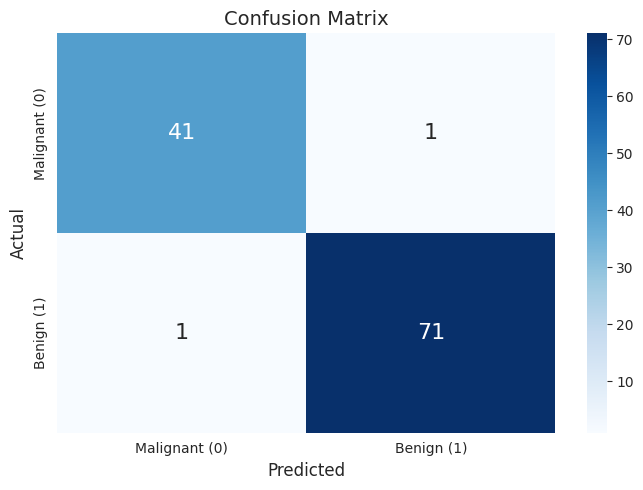

True Negatives  (TN): 41  — Correctly predicted Malignant
False Positives (FP): 1  — Predicted Benign, was Malignant
False Negatives (FN): 1  — Predicted Malignant, was Benign
True Positives  (TP): 71  — Correctly predicted Benign


In [136]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            annot_kws={'size': 16})
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN): {tn}  — Correctly predicted Malignant")
print(f"False Positives (FP): {fp}  — Predicted Benign, was Malignant")
print(f"False Negatives (FN): {fn}  — Predicted Malignant, was Benign")
print(f"True Positives  (TP): {tp}  — Correctly predicted Benign")

### 12.3 Precision, Recall, and F1-Score

These metrics are derived from the confusion matrix and each captures a different aspect of model quality:

**Precision:** Of all the samples the model predicted as positive (class 1), how many were actually positive?

$$\text{Precision} = \frac{TP}{TP + FP}$$

High precision means few false alarms. This matters when the **cost of a false positive** is high (e.g., flagging a legitimate email as spam).

**Recall (Sensitivity):** Of all the samples that were actually positive, how many did the model catch?

$$\text{Recall} = \frac{TP}{TP + FN}$$

High recall means few misses. This matters when the **cost of a false negative** is high (e.g., failing to detect a malignant tumor).

**F1-Score:** The harmonic mean of precision and recall. It balances both concerns:

$$F1 = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

**Task:** Print the full classification report.

In [137]:
# Print the classification report using classification_report(y_test, y_pred)
# Set target_names=['Malignant (0)', 'Benign (1)'] for readable output

print("Classification Report:")
print("=" * 55)
print(classification_report(y_test, y_pred,
                            target_names=['Malignant (0)', 'Benign (1)']))

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.98      0.98      0.98        42
   Benign (1)       0.99      0.99      0.99        72

     accuracy                           0.98       114
    macro avg       0.98      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



### 12.4 ROC Curve and AUC Score

The **ROC curve** (Receiver Operating Characteristic) is one of the most important evaluation tools in classification. It plots the **True Positive Rate** (Recall) against the **False Positive Rate** at various threshold values.

- A perfect model hugs the top-left corner (TPR = 1, FPR = 0)
- A random model follows the diagonal

The **AUC** (Area Under the Curve) summarizes the ROC curve in a single number:
- AUC = 1.0 → perfect classifier
- AUC = 0.5 → random classifier (no discrimination)
- AUC < 0.5 → worse than random

**Task:** Plot the ROC curve and compute the AUC score.

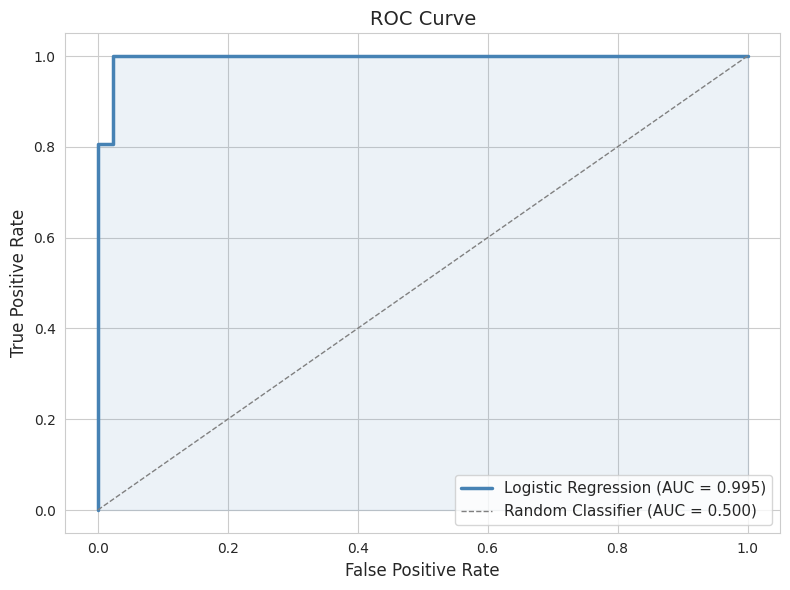

AUC Score: 0.9954


In [138]:
y_prob = y_proba[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2.5,
         label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1,
         label='Random Classifier (AUC = 0.500)')

plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')

plt.title('ROC Curve', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc:.4f}")

## 13. Understanding the Decision Threshold

By default, Logistic Regression uses a threshold of 0.5 to convert probabilities into class labels. But this threshold is **not fixed** — you can change it depending on the problem.

- **Lower threshold (e.g., 0.3):** The model predicts class 1 more often → higher recall, lower precision
- **Higher threshold (e.g., 0.7):** The model predicts class 1 less often → higher precision, lower recall

In cancer detection, we might lower the threshold to catch more malignant cases (at the cost of more false positives). In spam filtering, we might raise it to avoid flagging legitimate emails.

**Task:** Experiment with different thresholds and see how precision and recall change.

In [139]:
y_prob = y_proba[:, 1]

thresholds_to_test = [0.3, 0.5, 0.7]

for thresh in thresholds_to_test:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    acc = accuracy_score(y_test, y_pred_thresh)

    print(f"\n{'='*55}")
    print(f"  THRESHOLD = {thresh}  |  Accuracy = {acc:.4f}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred_thresh,
                                target_names=['Malignant (0)', 'Benign (1)']))


  THRESHOLD = 0.3  |  Accuracy = 0.9825
               precision    recall  f1-score   support

Malignant (0)       1.00      0.95      0.98        42
   Benign (1)       0.97      1.00      0.99        72

     accuracy                           0.98       114
    macro avg       0.99      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114


  THRESHOLD = 0.5  |  Accuracy = 0.9825
               precision    recall  f1-score   support

Malignant (0)       0.98      0.98      0.98        42
   Benign (1)       0.99      0.99      0.99        72

     accuracy                           0.98       114
    macro avg       0.98      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114


  THRESHOLD = 0.7  |  Accuracy = 0.9474
               precision    recall  f1-score   support

Malignant (0)       0.89      0.98      0.93        42
   Benign (1)       0.99      0.93      0.96        72

     accuracy                           0.95

## 14. Comparing Train vs Test Performance

Just like we did for Linear Regression, let us check if the model is overfitting or underfitting by comparing its performance on the training set vs the test set.

**Task:** Compute and compare accuracy and AUC on both sets.

In [140]:
y_train_pred = model.predict(X_train_scaled)
y_train_proba = model.predict_proba(X_train_scaled)[:, 1]

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

train_auc = roc_auc_score(y_train, y_train_proba)
test_auc = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("  TRAIN vs TEST COMPARISON")
print("=" * 50)
print(f"  {'Metric':<12} {'Train':>10} {'Test':>10} {'Gap':>10}")
print(f"  {'-'*12} {'-'*10} {'-'*10} {'-'*10}")
print(f"  {'Accuracy':<12} {train_acc:>10.4f} {test_acc:>10.4f} {train_acc - test_acc:>10.4f}")
print(f"  {'AUC':<12} {train_auc:>10.4f} {test_auc:>10.4f} {train_auc - test_auc:>10.4f}")
print("=" * 50)

acc_gap = train_acc - test_acc
if acc_gap < 0.03:
    print("\n  → Scores are very close. The model generalizes well.")
elif acc_gap < 0.10:
    print("\n  → Some gap. Mild overfitting possible.")
else:
    print("\n  → Large gap. The model is likely overfitting.")

  TRAIN vs TEST COMPARISON
  Metric            Train       Test        Gap
  ------------ ---------- ---------- ----------
  Accuracy         0.9890     0.9825     0.0066
  AUC              0.9975     0.9954     0.0021

  → Scores are very close. The model generalizes well.
